# Notebook 01 — Reciprocal Lattice and Brillouin Zone Construction

Pure-geometry construction of the 2D square reciprocal lattice and the first two Brillouin zones. No diagonalization is performed in this notebook.

- Reciprocal primitive vectors: $\mathbf{b}_1 = (2\pi, 0)$, $\mathbf{b}_2 = (0, 2\pi)$ (lattice constant $a = 1$).
- First BZ: Wigner–Seitz cell of the reciprocal lattice → the square $[-\pi, \pi]^2$.
- Second BZ: four right triangles outside BZ1 bounded by the perpendicular bisectors of the diagonal nearest neighbors at $(\pm 2\pi, \pm 2\pi)$.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

from src.lattice import (
    reciprocal_lattice_points,
    first_bz_corners,
    second_bz_triangles,
    perpendicular_bisectors_nearest_neighbors,
    high_symmetry_points,
)

FIG_DIR = ROOT / "figures" / "01_bz"
FIG_DIR.mkdir(parents=True, exist_ok=True)

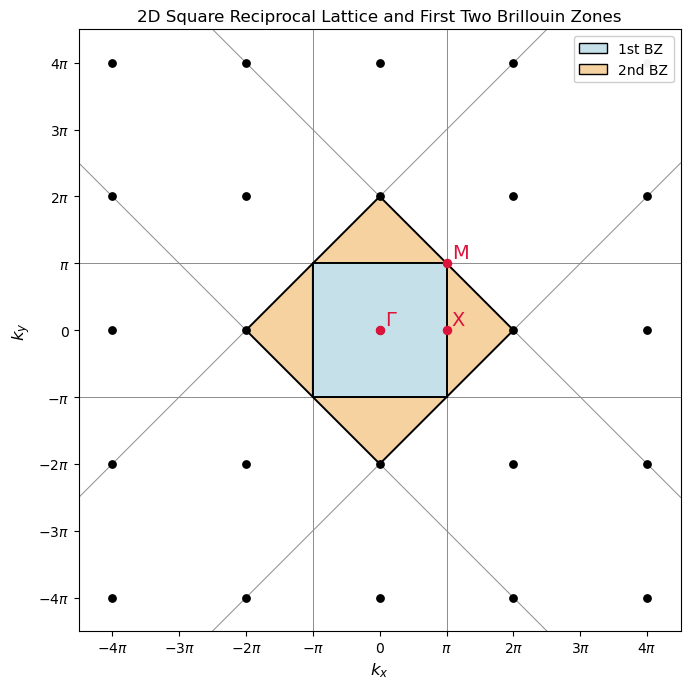

In [2]:
fig, ax = plt.subplots(figsize=(7.0, 7.0))

LIM = 4.5 * np.pi
ax.set_xlim(-LIM, LIM)
ax.set_ylim(-LIM, LIM)
ax.set_aspect("equal")

# Shaded second BZ (drawn first so BZ1 sits cleanly on top of any seams).
for tri in second_bz_triangles():
    ax.add_patch(Polygon(tri, closed=True, facecolor="#f6d2a1",
                         edgecolor="black", linewidth=1.4, zorder=3))

# Shaded first BZ.
ax.add_patch(Polygon(first_bz_corners(), closed=True, facecolor="#c5e0e8",
                     edgecolor="black", linewidth=1.4, zorder=4))

# Perpendicular bisectors of the 8 nearest neighbors as thin gray lines.
for p1, p2 in perpendicular_bisectors_nearest_neighbors():
    ax.axline(p1, p2, color="0.55", linewidth=0.7, zorder=1)

# 5x5 grid of reciprocal lattice points (m, n in {-2, ..., 2}, scaled by 2*pi).
pts = reciprocal_lattice_points(N_max=2)
ax.scatter(pts[:, 0], pts[:, 1], color="black", s=28, zorder=5)

# High-symmetry points on BZ1.
hs = high_symmetry_points()
label_offsets = {"Gamma": (0.25, 0.25), "X": (0.25, 0.25), "M": (0.25, 0.25)}
display_names = {"Gamma": r"$\Gamma$", "X": "X", "M": "M"}
for name, k in hs.items():
    ax.scatter(*k, color="crimson", s=34, zorder=6)
    dx, dy = label_offsets[name]
    ax.annotate(display_names[name], xy=k, xytext=(k[0] + dx, k[1] + dy),
                fontsize=14, color="crimson", zorder=7)

ax.set_xlabel(r"$k_x$", fontsize=12)
ax.set_ylabel(r"$k_y$", fontsize=12)
ax.set_title("2D Square Reciprocal Lattice and First Two Brillouin Zones")

ticks = np.arange(-4, 5) * np.pi
tick_labels = [r"$-4\pi$", r"$-3\pi$", r"$-2\pi$", r"$-\pi$",
               "0", r"$\pi$", r"$2\pi$", r"$3\pi$", r"$4\pi$"]
ax.set_xticks(ticks); ax.set_xticklabels(tick_labels)
ax.set_yticks(ticks); ax.set_yticklabels(tick_labels)

ax.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, fc="#c5e0e8", ec="black", label="1st BZ"),
        plt.Rectangle((0, 0), 1, 1, fc="#f6d2a1", ec="black", label="2nd BZ"),
    ],
    loc="upper right",
    framealpha=0.95,
)

fig.tight_layout()
fig.savefig(FIG_DIR / "figure_01_bz_construction.png", dpi=180, bbox_inches="tight")
plt.show()